# PRX Quantum 2023 AR / DR / ADR Rydberg gate reproduction

This notebook follows Jandura, Thompson, and Pupillo, *Optimizing Rydberg Gates for Logical-Qubit Performance*, PRX Quantum 4, 020336 (2023), DOI `10.1103/PRXQuantum.4.020336`, arXiv `2210.06879`.

The implementation below uses the paper's optimization structure:

- AR is a full CZ pulse optimized with the first-order amplitude-sensitivity objective.
- DR and ADR are optimized as `controlled-Rz(pi/2)` half-pulses.
- The full DR/ADR gate is made by applying the same half-pulse twice.
- The Doppler detuning sign is reversed in the second half.
- Detuning robustness includes both atom-1 and atom-2 first-order sensitivity directions.

The optimizer is a notebook-local GRAPE-style implementation using analytic Frechet derivatives. It does not import any optimized pulse from the paper; TO, AR, DR, and ADR are all optimized from deterministic random initial phase profiles.


## Paper optimization settings used here

For AR, the paper expands each branch state as

```math
|\psi_q\rangle = |\psi_q^{(0)}\rangle + \epsilon |\psi_q^{(1)}\rangle + O(\epsilon^2)
```

and minimizes

```math
J_{AR} = 1-F + \sum_q \langle\psi_q^{(1)}|\psi_q^{(1)}\rangle.
```

For DR, the optimized object is not a complete CZ gate. It is a half-pulse implementing `controlled-Rz(pi/2)`, with

```math
\theta_{11}-\theta_{10}-\theta_{01} = (2n+1/2)\pi.
```

The first-order detuning error must have no component orthogonal to the original computational state:

```math
(I-|q\rangle\langle q|)|\psi_q^{(1,j)}(\tau)\rangle = 0.
```

The full Doppler-robust gate is then

```math
\Omega_{full}(t) = [\Omega_{half}(t), \Omega_{half}(t)],
\qquad
\Delta_j \rightarrow -\Delta_j
```

in the second half. This repeated-half construction is not an unconditional copy-paste of the waveform: it assumes a physical Doppler-reversal mechanism between the two identical halves. In the switch method, **switch method reverses k** by reversing the laser direction. In the wait method, **wait method reverses v** by **waiting for a time pi / omega_trap**, i.e. half of the motional period, so `Delta_j = k v_j` changes sign. The reduced simulation below represents only this ideal sign flip in the detuning trace; it does not simulate the idle wait dynamics. ADR uses the same half-pulse construction but adds the amplitude-sensitivity objective to the DR objective.


## Imports

Purpose: import numerical tools, set a writable Matplotlib cache, and make repository modules importable.

Inputs: none.

Outputs: package imports and `ROOT`.

Assumptions: the project virtual environment has NumPy, SciPy, Matplotlib, and the local `neutral_yb` package available.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-neutral-yb")

import matplotlib.pyplot as plt
from IPython.display import Image, display
import numpy as np
from scipy.linalg import expm, expm_frechet
from scipy.optimize import least_squares, minimize

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from neutral_yb.analysis.noise_tolerant_rydberg import (
    blockade_branch_hamiltonians,
    detuning_noise_hamiltonians,
    propagate_blockade_branches,
)


## Paper metadata

Purpose: keep the target paper attached to the executed output.

Inputs: bibliographic fields.

Outputs: immutable metadata object.

Assumptions: this notebook reads source information but does not edit bibliography files.


In [2]:
@dataclass(frozen=True)
class PaperMetadata:
    title: str
    authors: tuple[str, ...]
    journal: str
    year: int
    doi: str
    arxiv: str


In [3]:
prxq_paper = PaperMetadata(
    title="Optimizing Rydberg Gates for Logical-Qubit Performance",
    authors=("Sven Jandura", "Jeff D. Thompson", "Guido Pupillo"),
    journal="PRX Quantum 4, 020336",
    year=2023,
    doi="10.1103/PRXQuantum.4.020336",
    arxiv="2210.06879",
)
prxq_paper


PaperMetadata(title='Optimizing Rydberg Gates for Logical-Qubit Performance', authors=('Sven Jandura', 'Jeff D. Thompson', 'Guido Pupillo'), journal='PRX Quantum 4, 020336', year=2023, doi='10.1103/PRXQuantum.4.020336', arxiv='2210.06879')

## Phase helpers

Purpose: normalize phase aliases and keep phase residuals on the principal branch.

Inputs: real phase values.

Outputs: normalized phase arrays or wrapped scalar phase errors.

Assumptions: `2*pi` phase shifts are physically equivalent.


In [4]:
def normalize_phases(phases: np.ndarray) -> np.ndarray:
    return np.mod(np.asarray(phases, dtype=np.float64), 2.0 * np.pi)

def wrap_phase(angle: float) -> float:
    return float(np.angle(np.exp(1j * float(angle))))


## Atom-resolved amplitude perturbation Hamiltonian

Purpose: construct first-order Hamiltonians for independent amplitude errors on atom 1 or atom 2.

Inputs: slot phase and atom index.

Outputs: perturbation Hamiltonians for the `10`, `01`, and `11` branches.

Assumptions: the nominal `11` branch is represented in the `|11>, |W+>, |W->` basis. A differential amplitude error couples `|11>` to `|W->` at first order.


In [5]:
def amplitude_noise_hamiltonians_atom(phase: float, atom: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    omega = np.exp(1j * float(phase))
    h10 = np.zeros((2, 2), dtype=np.complex128)
    h01 = np.zeros((2, 2), dtype=np.complex128)
    h11 = np.zeros((3, 3), dtype=np.complex128)

    if atom == 1:
        h10[0, 1] = np.conj(omega) / 2.0
        h10[1, 0] = omega / 2.0
        wminus_sign = 1.0
    elif atom == 2:
        h01[0, 1] = np.conj(omega) / 2.0
        h01[1, 0] = omega / 2.0
        wminus_sign = -1.0
    else:
        raise ValueError("atom must be 1 or 2")

    h11[0, 1] = np.conj(omega) / (2.0 * np.sqrt(2.0))
    h11[1, 0] = omega / (2.0 * np.sqrt(2.0))
    h11[0, 2] = wminus_sign * np.conj(omega) / (2.0 * np.sqrt(2.0))
    h11[2, 0] = wminus_sign * omega / (2.0 * np.sqrt(2.0))
    return h10, h01, h11


## First-order sensitivity propagation

Purpose: propagate zero-order and first-order states for one atom-resolved perturbation direction.

Inputs: phase samples, duration, perturbation kind, and atom index.

Outputs: nominal branch states and first-order sensitivity states.

Assumptions: slot Hamiltonians are piecewise constant; Frechet derivatives propagate the first-order inhomogeneous equation used by GRAPE.


In [6]:
def propagate_first_order_atom(
    phases: np.ndarray,
    *,
    total_time: float,
    noise_kind: str,
    atom: int,
) -> tuple[tuple[np.ndarray, np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray, np.ndarray]]:
    phases = normalize_phases(phases)
    dt = float(total_time) / phases.size
    states = [
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0, 0.0], dtype=np.complex128),
    ]
    sensitivities = [np.zeros_like(state) for state in states]

    for phase in phases:
        nominal_hamiltonians = blockade_branch_hamiltonians(float(phase))
        if noise_kind == "amplitude":
            noise_hamiltonians = amplitude_noise_hamiltonians_atom(float(phase), atom)
        elif noise_kind == "detuning":
            noise_hamiltonians = detuning_noise_hamiltonians(
                detuning_1_sign=1.0 if atom == 1 else 0.0,
                detuning_2_sign=1.0 if atom == 2 else 0.0,
            )
        else:
            raise ValueError("noise_kind must be 'amplitude' or 'detuning'")

        for branch_index, (h0, h1) in enumerate(zip(nominal_hamiltonians, noise_hamiltonians, strict=True)):
            generator = -1j * h0 * dt
            propagator = expm(generator)
            frechet = expm_frechet(generator, -1j * h1 * dt, compute_expm=False)
            sensitivities[branch_index] = propagator @ sensitivities[branch_index] + frechet @ states[branch_index]
            states[branch_index] = propagator @ states[branch_index]

    return (states[0], states[1], states[2]), (sensitivities[0], sensitivities[1], sensitivities[2])


## Branch evaluation

Purpose: evaluate a phase pulse under common amplitude error and atom-resolved detuning probes.

Inputs: phase samples, duration, amplitude error, detunings, and optional Doppler sign reversal.

Outputs: computational return amplitudes and full branch states.

Assumptions: Doppler sign reversal is applied exactly at the midpoint of a repeated half-pulse full gate.


In [7]:
def branch_amplitudes(
    phases: np.ndarray,
    *,
    total_time: float,
    amplitude_error: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    use_doppler_reversal: bool = False,
) -> tuple[complex, complex, complex, tuple[np.ndarray, np.ndarray, np.ndarray]]:
    phases = normalize_phases(phases)
    signs = np.ones(phases.size, dtype=np.float64)
    if use_doppler_reversal:
        signs[phases.size // 2 :] = -1.0
    states = propagate_blockade_branches(
        phases,
        total_time=float(total_time),
        amplitude_error=float(amplitude_error),
        detuning_1_trace=float(detuning_1) * signs,
        detuning_2_trace=float(detuning_2) * signs,
    )
    return complex(states[0][0]), complex(states[1][0]), complex(states[2][0]), states


## Repeated half-pulse construction

Purpose: construct the full DR/ADR pulse exactly as two identical half-pulses.

Inputs: half-pulse phase samples.

Outputs: full-gate phase samples with the half-pulse repeated.

Assumptions: the Doppler sign reversal is not encoded in the phase vector; it is encoded in the detuning trace during evaluation.


In [8]:
def make_repeated_half_pulse(half_phases: np.ndarray) -> np.ndarray:
    half = normalize_phases(half_phases)
    return np.concatenate([half, half])


## Fidelity and phase-target residual

Purpose: score diagonal CZ fidelity and build nominal residuals for either a full CZ or a `controlled-Rz(pi/2)` half-pulse.

Inputs: branch amplitudes, local phases, phase samples, duration, and target entangling phase.

Outputs: optimized fidelity or least-squares residual.

Assumptions: full CZ uses target entangling phase `pi`; DR/ADR half-pulse uses target entangling phase `pi/2`.


In [9]:
def diagonal_cz_fidelity(alpha10: complex, alpha01: complex, beta11: complex, theta10: float, theta01: float) -> float:
    overlap = 1.0 + np.exp(-1j * theta10) * alpha10 + np.exp(-1j * theta01) * alpha01
    overlap -= np.exp(-1j * (theta10 + theta01)) * beta11
    return float(abs(overlap) ** 2 / 16.0)

def optimize_local_phases(alpha10: complex, alpha01: complex, beta11: complex) -> tuple[float, float, float]:
    def objective(variables: np.ndarray) -> float:
        return -diagonal_cz_fidelity(alpha10, alpha01, beta11, variables[0], variables[1])
    best = None
    for start in (np.array([np.angle(alpha10), np.angle(alpha01)]), np.zeros(2), np.pi * np.ones(2)):
        result = minimize(objective, start, method="Nelder-Mead", options={"maxiter": 400})
        if best is None or result.fun < best.fun:
            best = result
    assert best is not None
    return float(np.mod(best.x[0], 2.0 * np.pi)), float(np.mod(best.x[1], 2.0 * np.pi)), -float(best.fun)

def phase_gate_residual(phases: np.ndarray, *, total_time: float, target_entangling_phase: float, weight: float = 10.0) -> np.ndarray:
    alpha10, alpha01, beta11, states = branch_amplitudes(phases, total_time=total_time)
    residuals: list[float] = [weight * (1.0 - abs(value)) for value in (alpha10, alpha01, beta11)]
    entangling_phase = np.angle(beta11) - np.angle(alpha10) - np.angle(alpha01)
    residuals.append(weight * wrap_phase(entangling_phase - float(target_entangling_phase)))
    for state in states:
        for component in state[1:]:
            residuals.extend([float(component.real), float(component.imag)])
    return np.asarray(residuals, dtype=np.float64)


## Paper objective residuals

Purpose: build AR, DR, and ADR first-order objectives using atom-resolved perturbation directions.

Inputs: phase samples, duration, and target kind.

Outputs: real least-squares residual vectors.

Assumptions: `detuning_atoms=(1, 2)` implements the paper's `sum_{j,q}` detuning objective. DR projects out the computational return direction. ADR adds AR and DR residuals on the half-pulse.


In [10]:
def first_order_residual(
    phases: np.ndarray,
    *,
    total_time: float,
    noise_kind: str,
    atoms: tuple[int, ...] = (1, 2),
    project_orthogonal: bool = False,
) -> np.ndarray:
    residuals: list[float] = []
    for atom in atoms:
        _nominal, sensitivities = propagate_first_order_atom(
            phases,
            total_time=total_time,
            noise_kind=noise_kind,
            atom=atom,
        )
        for sensitivity in sensitivities:
            selected = sensitivity[1:] if project_orthogonal else sensitivity
            for component in selected:
                residuals.extend([float(component.real), float(component.imag)])
    return np.asarray(residuals, dtype=np.float64)

def paper_method_objective(
    phases: np.ndarray,
    *,
    total_time: float,
    target: str,
    detuning_atoms: tuple[int, int] = (1, 2),
) -> np.ndarray:
    target = target.upper()
    if target == "AR":
        return np.concatenate([
            50.0 * phase_gate_residual(phases, total_time=total_time, target_entangling_phase=np.pi),
            first_order_residual(phases, total_time=total_time, noise_kind="amplitude", atoms=(1, 2)),
        ])
    if target == "DR":
        return np.concatenate([
            50.0 * phase_gate_residual(phases, total_time=total_time, target_entangling_phase=0.5 * np.pi),
            4.0 * first_order_residual(
                phases,
                total_time=total_time,
                noise_kind="detuning",
                atoms=detuning_atoms,
                project_orthogonal=True,
            ),
        ])
    if target == "ADR":
        return np.concatenate([
            50.0 * phase_gate_residual(phases, total_time=total_time, target_entangling_phase=0.5 * np.pi),
            first_order_residual(phases, total_time=total_time, noise_kind="amplitude", atoms=(1, 2)),
            4.0 * first_order_residual(
                phases,
                total_time=total_time,
                noise_kind="detuning",
                atoms=detuning_atoms,
                project_orthogonal=True,
            ),
        ])
    raise ValueError("target must be AR, DR, or ADR")


## Notebook-local analytic GRAPE helpers

The paper uses GRAPE on piecewise-constant controls with `N >> 1` slots and searches pulse duration. The helpers below keep the implementation inside this notebook, as requested. AR/DR/ADR do not use the TO pulse or any published optimized pulse as an initial condition. Instead, each duration is optimized from deterministic random initial phase profiles.

The analytic gradient follows the existing project GRAPE pattern: prefix states, suffix propagators, and `expm_frechet` for each slot derivative. For first-order sensitivity objectives, the inhomogeneous equation is represented by the augmented slot generator `[[G0, 0], [G1, G0]]`, so the derivative of the final sensitivity state is also obtained analytically by a Frechet derivative of the augmented propagator.


In [11]:
def phase_derivative_hamiltonians(phase: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    omega = np.exp(1j * float(phase))
    domega = 1j * omega
    dconj = -1j * np.conj(omega)

    dh10 = np.zeros((2, 2), dtype=np.complex128)
    dh01 = np.zeros((2, 2), dtype=np.complex128)
    dh11 = np.zeros((3, 3), dtype=np.complex128)

    dh10[0, 1] = dconj / 2.0
    dh10[1, 0] = domega / 2.0
    dh01[0, 1] = dconj / 2.0
    dh01[1, 0] = domega / 2.0
    dh11[0, 1] = dconj / np.sqrt(2.0)
    dh11[1, 0] = domega / np.sqrt(2.0)
    return dh10, dh01, dh11


def amplitude_noise_phase_derivative_hamiltonians_atom(phase: float, atom: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    omega = np.exp(1j * float(phase))
    domega = 1j * omega
    dconj = -1j * np.conj(omega)
    dh10 = np.zeros((2, 2), dtype=np.complex128)
    dh01 = np.zeros((2, 2), dtype=np.complex128)
    dh11 = np.zeros((3, 3), dtype=np.complex128)

    if atom == 1:
        dh10[0, 1] = dconj / 2.0
        dh10[1, 0] = domega / 2.0
        wminus_sign = 1.0
    elif atom == 2:
        dh01[0, 1] = dconj / 2.0
        dh01[1, 0] = domega / 2.0
        wminus_sign = -1.0
    else:
        raise ValueError("atom must be 1 or 2")

    dh11[0, 1] = dconj / (2.0 * np.sqrt(2.0))
    dh11[1, 0] = domega / (2.0 * np.sqrt(2.0))
    dh11[0, 2] = wminus_sign * dconj / (2.0 * np.sqrt(2.0))
    dh11[2, 0] = wminus_sign * domega / (2.0 * np.sqrt(2.0))
    return dh10, dh01, dh11


def branch_states_and_phase_jacobian(
    phases: np.ndarray,
    *,
    total_time: float,
) -> tuple[tuple[np.ndarray, np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray, np.ndarray]]:
    phases = normalize_phases(phases)
    dt = float(total_time) / phases.size
    initial_states = (
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0, 0.0], dtype=np.complex128),
    )
    final_states: list[np.ndarray] = []
    jacobians: list[np.ndarray] = []

    for branch_index, initial_state in enumerate(initial_states):
        unitaries: list[np.ndarray] = []
        prefixes: list[np.ndarray] = [initial_state]
        state = np.array(initial_state, copy=True)
        for phase in phases:
            h0 = blockade_branch_hamiltonians(float(phase))[branch_index]
            u = expm(-1j * h0 * dt)
            unitaries.append(u)
            state = u @ state
            prefixes.append(state)

        suffixes: list[np.ndarray] = [np.eye(initial_state.size, dtype=np.complex128) for _ in phases]
        suffix = np.eye(initial_state.size, dtype=np.complex128)
        for slot in range(phases.size - 1, -1, -1):
            suffixes[slot] = suffix
            suffix = suffix @ unitaries[slot]

        jac = np.zeros((phases.size, initial_state.size), dtype=np.complex128)
        for slot, phase in enumerate(phases):
            h0 = blockade_branch_hamiltonians(float(phase))[branch_index]
            dh0 = phase_derivative_hamiltonians(float(phase))[branch_index]
            du = expm_frechet(-1j * h0 * dt, -1j * dh0 * dt, compute_expm=False)
            jac[slot] = suffixes[slot] @ du @ prefixes[slot]
        final_states.append(prefixes[-1])
        jacobians.append(jac)

    return (final_states[0], final_states[1], final_states[2]), (jacobians[0], jacobians[1], jacobians[2])



def phase_smoothness_residual_and_jacobian(
    phases: np.ndarray,
    *,
    first_weight: float = 0.0,
    second_weight: float = 0.0,
) -> tuple[np.ndarray, np.ndarray]:
    phases = normalize_phases(phases)
    n = int(phases.size)
    residuals: list[float] = []
    jac_rows: list[np.ndarray] = []

    if first_weight > 0.0 and n >= 2:
        for index in range(n - 1):
            row = np.zeros(n, dtype=np.float64)
            row[index] = -float(first_weight)
            row[index + 1] = float(first_weight)
            residuals.append(float(first_weight) * wrap_phase(float(phases[index + 1] - phases[index])))
            jac_rows.append(row)

    if second_weight > 0.0 and n >= 3:
        wrapped_diffs = np.array(
            [wrap_phase(float(phases[index + 1] - phases[index])) for index in range(n - 1)],
            dtype=np.float64,
        )
        for index in range(n - 2):
            row = np.zeros(n, dtype=np.float64)
            row[index] = float(second_weight)
            row[index + 1] = -2.0 * float(second_weight)
            row[index + 2] = float(second_weight)
            residuals.append(float(second_weight) * wrap_phase(float(wrapped_diffs[index + 1] - wrapped_diffs[index])))
            jac_rows.append(row)

    if not residuals:
        return np.zeros(0, dtype=np.float64), np.zeros((0, n), dtype=np.float64)
    return np.asarray(residuals, dtype=np.float64), np.vstack(jac_rows)


def smoothness_weights_for_target(target: str) -> tuple[float, float]:
    target = target.upper()
    first_weights = globals().get("smoothness_first_weights", {})
    second_weights = globals().get("smoothness_second_weights", {})
    default_first = float(globals().get("smoothness_first_weight", 0.0))
    default_second = float(globals().get("smoothness_second_weight", 0.0))
    return float(first_weights.get(target, default_first)), float(second_weights.get(target, default_second))


def phase_gate_residual_and_jacobian(
    phases: np.ndarray,
    *,
    total_time: float,
    target_entangling_phase: float,
    weight: float = 10.0,
    smoothness_first_weight: float = 0.0,
    smoothness_second_weight: float = 0.0,
) -> tuple[np.ndarray, np.ndarray]:
    states, state_jacs = branch_states_and_phase_jacobian(phases, total_time=total_time)
    amplitudes = [complex(states[0][0]), complex(states[1][0]), complex(states[2][0])]
    amp_jacs = [state_jacs[0][:, 0], state_jacs[1][:, 0], state_jacs[2][:, 0]]
    residuals: list[float] = []
    jac_rows: list[np.ndarray] = []
    eps = 1e-14

    for amplitude, d_amplitude in zip(amplitudes, amp_jacs, strict=True):
        magnitude = abs(amplitude)
        residuals.append(float(weight * (1.0 - magnitude)))
        if magnitude > eps:
            jac_rows.append(-weight * np.real(np.conj(amplitude) * d_amplitude) / magnitude)
        else:
            jac_rows.append(np.zeros(phases.size, dtype=np.float64))

    alpha10, alpha01, beta11 = amplitudes
    d_alpha10, d_alpha01, d_beta11 = amp_jacs
    entangling_phase = np.angle(beta11) - np.angle(alpha10) - np.angle(alpha01)
    residuals.append(float(weight * wrap_phase(entangling_phase - float(target_entangling_phase))))
    phase_grad = np.imag(d_beta11 / beta11 - d_alpha10 / alpha10 - d_alpha01 / alpha01)
    jac_rows.append(weight * np.asarray(phase_grad, dtype=np.float64))

    for state, jac in zip(states, state_jacs, strict=True):
        for component_index in range(1, state.size):
            residuals.append(float(state[component_index].real))
            jac_rows.append(np.asarray(jac[:, component_index].real, dtype=np.float64))
            residuals.append(float(state[component_index].imag))
            jac_rows.append(np.asarray(jac[:, component_index].imag, dtype=np.float64))

    smooth_residual, smooth_jacobian = phase_smoothness_residual_and_jacobian(
        phases,
        first_weight=float(smoothness_first_weight),
        second_weight=float(smoothness_second_weight),
    )
    if smooth_residual.size:
        residuals.extend(float(value) for value in smooth_residual)
        jac_rows.extend(np.asarray(row, dtype=np.float64) for row in smooth_jacobian)

    return np.asarray(residuals, dtype=np.float64), np.vstack(jac_rows)


def augmented_first_order_states_and_phase_jacobian(
    phases: np.ndarray,
    *,
    total_time: float,
    noise_kind: str,
    atom: int,
) -> tuple[tuple[np.ndarray, np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray, np.ndarray]]:
    phases = normalize_phases(phases)
    dt = float(total_time) / phases.size
    branch_dims = (2, 2, 3)
    initial_nominal = (
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0, 0.0], dtype=np.complex128),
    )
    final_sensitivities: list[np.ndarray] = []
    sensitivity_jacs: list[np.ndarray] = []

    for branch_index, dim in enumerate(branch_dims):
        initial_aug = np.concatenate([initial_nominal[branch_index], np.zeros(dim, dtype=np.complex128)])
        propagators: list[np.ndarray] = []
        prefixes: list[np.ndarray] = [initial_aug]
        aug_state = np.array(initial_aug, copy=True)

        for phase in phases:
            h0 = blockade_branch_hamiltonians(float(phase))[branch_index]
            if noise_kind == "amplitude":
                h1 = amplitude_noise_hamiltonians_atom(float(phase), atom)[branch_index]
            elif noise_kind == "detuning":
                h1 = detuning_noise_hamiltonians(
                    detuning_1_sign=1.0 if atom == 1 else 0.0,
                    detuning_2_sign=1.0 if atom == 2 else 0.0,
                )[branch_index]
            else:
                raise ValueError("noise_kind must be 'amplitude' or 'detuning'")
            block_generator = np.block([
                [-1j * h0 * dt, np.zeros((dim, dim), dtype=np.complex128)],
                [-1j * h1 * dt, -1j * h0 * dt],
            ])
            propagator = expm(block_generator)
            propagators.append(propagator)
            aug_state = propagator @ aug_state
            prefixes.append(aug_state)

        suffixes: list[np.ndarray] = [np.eye(2 * dim, dtype=np.complex128) for _ in phases]
        suffix = np.eye(2 * dim, dtype=np.complex128)
        for slot in range(phases.size - 1, -1, -1):
            suffixes[slot] = suffix
            suffix = suffix @ propagators[slot]

        jac = np.zeros((phases.size, dim), dtype=np.complex128)
        for slot, phase in enumerate(phases):
            h0 = blockade_branch_hamiltonians(float(phase))[branch_index]
            dh0 = phase_derivative_hamiltonians(float(phase))[branch_index]
            if noise_kind == "amplitude":
                h1 = amplitude_noise_hamiltonians_atom(float(phase), atom)[branch_index]
                dh1 = amplitude_noise_phase_derivative_hamiltonians_atom(float(phase), atom)[branch_index]
            else:
                h1 = detuning_noise_hamiltonians(
                    detuning_1_sign=1.0 if atom == 1 else 0.0,
                    detuning_2_sign=1.0 if atom == 2 else 0.0,
                )[branch_index]
                dh1 = np.zeros_like(h1)
            block_generator = np.block([
                [-1j * h0 * dt, np.zeros((dim, dim), dtype=np.complex128)],
                [-1j * h1 * dt, -1j * h0 * dt],
            ])
            d_block_generator = np.block([
                [-1j * dh0 * dt, np.zeros((dim, dim), dtype=np.complex128)],
                [-1j * dh1 * dt, -1j * dh0 * dt],
            ])
            d_propagator = expm_frechet(block_generator, d_block_generator, compute_expm=False)
            d_aug_state = suffixes[slot] @ d_propagator @ prefixes[slot]
            jac[slot] = d_aug_state[dim:]

        final_sensitivities.append(prefixes[-1][dim:])
        sensitivity_jacs.append(jac)

    return (
        final_sensitivities[0],
        final_sensitivities[1],
        final_sensitivities[2],
    ), (
        sensitivity_jacs[0],
        sensitivity_jacs[1],
        sensitivity_jacs[2],
    )


def first_order_residual_and_jacobian(
    phases: np.ndarray,
    *,
    total_time: float,
    noise_kind: str,
    atoms: tuple[int, ...] = (1, 2),
    project_orthogonal: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    residuals: list[float] = []
    jac_rows: list[np.ndarray] = []
    for atom in atoms:
        sensitivities, sensitivity_jacs = augmented_first_order_states_and_phase_jacobian(
            phases,
            total_time=total_time,
            noise_kind=noise_kind,
            atom=atom,
        )
        for sensitivity, jac in zip(sensitivities, sensitivity_jacs, strict=True):
            component_indices = range(1, sensitivity.size) if project_orthogonal else range(sensitivity.size)
            for component_index in component_indices:
                residuals.append(float(sensitivity[component_index].real))
                jac_rows.append(np.asarray(jac[:, component_index].real, dtype=np.float64))
                residuals.append(float(sensitivity[component_index].imag))
                jac_rows.append(np.asarray(jac[:, component_index].imag, dtype=np.float64))
    return np.asarray(residuals, dtype=np.float64), np.vstack(jac_rows)


def paper_method_residual_and_jacobian(
    phases: np.ndarray,
    *,
    total_time: float,
    target: str,
    detuning_atoms: tuple[int, int] = (1, 2),
) -> tuple[np.ndarray, np.ndarray]:
    target = target.upper()
    parts: list[np.ndarray] = []
    jac_parts: list[np.ndarray] = []
    target_phase = np.pi if target in {"TO", "AR"} else 0.5 * np.pi
    phase_residual, phase_jacobian = phase_gate_residual_and_jacobian(
        phases,
        total_time=total_time,
        target_entangling_phase=target_phase,
    )
    parts.append(50.0 * phase_residual)
    jac_parts.append(50.0 * phase_jacobian)
    smooth_first, smooth_second = smoothness_weights_for_target(target)
    smooth_residual, smooth_jacobian = phase_smoothness_residual_and_jacobian(
        phases,
        first_weight=smooth_first,
        second_weight=smooth_second,
    )
    if smooth_residual.size:
        parts.append(smooth_residual)
        jac_parts.append(smooth_jacobian)

    if target in {"AR", "ADR"}:
        amp_residual, amp_jacobian = first_order_residual_and_jacobian(
            phases,
            total_time=total_time,
            noise_kind="amplitude",
            atoms=(1, 2),
        )
        parts.append(amp_residual)
        jac_parts.append(amp_jacobian)
    if target in {"DR", "ADR"}:
        det_residual, det_jacobian = first_order_residual_and_jacobian(
            phases,
            total_time=total_time,
            noise_kind="detuning",
            atoms=detuning_atoms,
            project_orthogonal=True,
        )
        parts.append(4.0 * det_residual)
        jac_parts.append(4.0 * det_jacobian)
    if target not in {"AR", "DR", "ADR"}:
        raise ValueError("target must be AR, DR, or ADR")
    return np.concatenate(parts), np.vstack(jac_parts)


def scalar_objective_and_gradient_from_residual(
    residual: np.ndarray,
    jacobian: np.ndarray,
) -> tuple[float, np.ndarray]:
    return float(np.dot(residual, residual)), 2.0 * jacobian.T @ residual


def nominal_objective_and_gradient(
    phases: np.ndarray,
    *,
    total_time: float,
    target_entangling_phase: float,
    smoothness_first_weight: float = 0.0,
    smoothness_second_weight: float = 0.0,
) -> tuple[float, np.ndarray]:
    residual, jacobian = phase_gate_residual_and_jacobian(
        phases,
        total_time=total_time,
        target_entangling_phase=target_entangling_phase,
        smoothness_first_weight=smoothness_first_weight,
        smoothness_second_weight=smoothness_second_weight,
    )
    return scalar_objective_and_gradient_from_residual(residual, jacobian)


def paper_objective_and_gradient(
    phases: np.ndarray,
    *,
    total_time: float,
    target: str,
) -> tuple[float, np.ndarray]:
    residual, jacobian = paper_method_residual_and_jacobian(
        phases,
        total_time=total_time,
        target=target,
        detuning_atoms=(1, 2),
    )
    return scalar_objective_and_gradient_from_residual(residual, jacobian)


def analytic_gradient_check(
    phases: np.ndarray,
    *,
    total_time: float,
    target: str,
    indices: tuple[int, ...] = (0, -1),
    epsilon: float = 1e-6,
) -> list[dict[str, float | int]]:
    objective, gradient = paper_objective_and_gradient(phases, total_time=total_time, target=target)
    checks: list[dict[str, float | int]] = []
    for raw_index in indices:
        index = int(raw_index % phases.size)
        plus = np.array(phases, copy=True)
        minus = np.array(phases, copy=True)
        plus[index] += epsilon
        minus[index] -= epsilon
        objective_plus, _ = paper_objective_and_gradient(plus, total_time=total_time, target=target)
        objective_minus, _ = paper_objective_and_gradient(minus, total_time=total_time, target=target)
        finite_difference = (objective_plus - objective_minus) / (2.0 * epsilon)
        checks.append({
            "index": index,
            "objective": float(objective),
            "analytic": float(gradient[index]),
            "finite_difference": float(finite_difference),
            "abs_error": float(abs(gradient[index] - finite_difference)),
        })
    return checks


def optimize_nominal_phase_gate(
    initial_phases: np.ndarray,
    *,
    total_time: float,
    target_entangling_phase: float,
    max_nfev: int = 300,
    smoothness_first_weight: float = 0.0,
    smoothness_second_weight: float = 0.0,
) -> tuple[np.ndarray, object]:
    def residual(phases: np.ndarray) -> np.ndarray:
        return phase_gate_residual_and_jacobian(
            phases,
            total_time=total_time,
            target_entangling_phase=target_entangling_phase,
            smoothness_first_weight=smoothness_first_weight,
            smoothness_second_weight=smoothness_second_weight,
        )[0]

    def jacobian(phases: np.ndarray) -> np.ndarray:
        return phase_gate_residual_and_jacobian(
            phases,
            total_time=total_time,
            target_entangling_phase=target_entangling_phase,
            smoothness_first_weight=smoothness_first_weight,
            smoothness_second_weight=smoothness_second_weight,
        )[1]

    result = least_squares(
        residual,
        normalize_phases(initial_phases),
        jac=jacobian,
        bounds=(np.zeros(len(initial_phases)), np.full(len(initial_phases), 2.0 * np.pi)),
        max_nfev=max_nfev,
        xtol=1e-8,
        ftol=1e-8,
        gtol=1e-8,
    )
    return normalize_phases(result.x), result


def optimize_paper_target(
    initial_phases: np.ndarray,
    *,
    total_time: float,
    target: str,
    max_nfev: int = 250,
) -> tuple[np.ndarray, object]:
    def residual(phases: np.ndarray) -> np.ndarray:
        return paper_method_residual_and_jacobian(
            phases,
            total_time=total_time,
            target=target,
            detuning_atoms=(1, 2),
        )[0]

    def jacobian(phases: np.ndarray) -> np.ndarray:
        return paper_method_residual_and_jacobian(
            phases,
            total_time=total_time,
            target=target,
            detuning_atoms=(1, 2),
        )[1]

    result = least_squares(
        residual,
        normalize_phases(initial_phases),
        jac=jacobian,
        bounds=(np.zeros(len(initial_phases)), np.full(len(initial_phases), 2.0 * np.pi)),
        max_nfev=max_nfev,
        xtol=1e-9,
        ftol=1e-9,
        gtol=1e-9,
    )
    return normalize_phases(result.x), result

def make_random_phase_initializations(
    *,
    num_tslots: int,
    num_starts: int,
    seed: int,
) -> list[np.ndarray]:
    """Generate deterministic random phase profiles without using TO or paper pulses."""
    rng = np.random.default_rng(int(seed))
    seeds: list[np.ndarray] = []
    for _ in range(int(num_starts)):
        base_phase = rng.uniform(0.0, 2.0 * np.pi)
        increments = rng.normal(loc=0.0, scale=0.45, size=int(num_tslots))
        smooth_random_walk = base_phase + np.cumsum(increments)
        small_jitter = rng.normal(loc=0.0, scale=0.08, size=int(num_tslots))
        seeds.append(normalize_phases(smooth_random_walk + small_jitter))
    return seeds


@dataclass(frozen=True)
class FromZeroScanRecord:
    target: str
    duration: float
    start_index: int
    nominal_cost: float
    robust_cost: float
    nominal_success: bool
    robust_success: bool
    nominal_nfev: int
    robust_nfev: int


def robust_cost_value(phases: np.ndarray, *, total_time: float, target: str) -> float:
    residual = paper_method_objective(phases, total_time=total_time, target=target)
    return float(np.dot(residual, residual))


def optimize_target_from_zero_scan(
    *,
    target: str,
    duration_candidates: np.ndarray,
    num_tslots: int,
    num_random_starts: int,
    seed: int,
    nominal_max_nfev: int,
    robust_max_nfev: int,
) -> tuple[np.ndarray, float, object, list[FromZeroScanRecord]]:
    target = target.upper()
    target_phase = np.pi if target in {"TO", "AR"} else 0.5 * np.pi
    best_phases: np.ndarray | None = None
    best_duration: float | None = None
    best_result: object | None = None
    best_cost = np.inf
    records: list[FromZeroScanRecord] = []

    for duration in np.asarray(duration_candidates, dtype=np.float64):
        random_initializations = make_random_phase_initializations(
            num_tslots=int(num_tslots),
            num_starts=int(num_random_starts),
            seed=int(seed) + int(round(1000.0 * float(duration))),
        )
        for start_index, initial_phases in enumerate(random_initializations):
            nominal_smooth_first, nominal_smooth_second = smoothness_weights_for_target(target)
            nominal_phases, nominal_result = optimize_nominal_phase_gate(
                initial_phases,
                total_time=float(duration),
                target_entangling_phase=float(target_phase),
                max_nfev=int(nominal_max_nfev),
                smoothness_first_weight=nominal_smooth_first,
                smoothness_second_weight=nominal_smooth_second,
            )
            if target == "TO":
                robust_phases = nominal_phases
                robust_result = nominal_result
                robust_cost = float(2.0 * nominal_result.cost)
            else:
                robust_phases, robust_result = optimize_paper_target(
                    nominal_phases,
                    total_time=float(duration),
                    target=target,
                    max_nfev=int(robust_max_nfev),
                )
                robust_cost = robust_cost_value(robust_phases, total_time=float(duration), target=target)
            nominal_cost = float(2.0 * nominal_result.cost)
            nominal_ok = bool(nominal_result.success) or nominal_cost < 1e-6
            if target == "TO":
                robust_ok = nominal_ok
            else:
                robust_threshold = float(globals().get("robust_success_cost_thresholds", {}).get(target, np.inf))
                robust_ok = bool(robust_result.success) and robust_cost < robust_threshold
            records.append(
                FromZeroScanRecord(
                    target=target,
                    duration=float(duration),
                    start_index=int(start_index),
                    nominal_cost=float(nominal_cost),
                    robust_cost=float(robust_cost),
                    nominal_success=bool(nominal_ok),
                    robust_success=bool(robust_ok),
                    nominal_nfev=int(nominal_result.nfev),
                    robust_nfev=int(robust_result.nfev),
                )
            )
            if "write_progress" in globals():
                write_progress(
                    f"target={target} duration={float(duration):.6f} start={start_index} "
                    f"nominal_cost={nominal_cost:.6e} robust_cost={robust_cost:.6e} "
                    f"nfev={int(nominal_result.nfev)}+{int(robust_result.nfev)} "
                    f"nominal_ok={bool(nominal_ok)} robust_ok={bool(robust_ok)}"
                )
            if robust_cost < best_cost:
                best_cost = robust_cost
                best_phases = robust_phases
                best_duration = float(duration)
                best_result = robust_result

    if best_phases is None or best_duration is None or best_result is None:
        raise RuntimeError(f"No optimization records were produced for target {target}")
    return best_phases, best_duration, best_result, records


def print_scan_records(records: list[FromZeroScanRecord]) -> None:
    print("target  duration  start  nominal_cost  robust_cost  nominal_ok  robust_ok  nfev")
    for record in records:
        print(
            f"{record.target:>6}  {record.duration:8.3f}  {record.start_index:5d}  "
            f"{record.nominal_cost:12.4e}  {record.robust_cost:11.4e}  "
            f"{str(record.nominal_success):>10}  {str(record.robust_success):>9}  "
            f"{record.nominal_nfev:4d}+{record.robust_nfev:<4d}"
        )


## Analytic gradient check

Purpose: verify the notebook-local analytic GRAPE gradient before running any optimization.

Inputs: a deterministic small random pulse and representative AR/DR/ADR objectives.

Outputs: central finite-difference comparisons for selected phase slots.

Assumptions: this is a local derivative check for the implemented objective; it is not a physics result.


In [12]:
gradient_check_phases = make_random_phase_initializations(num_tslots=8, num_starts=1, seed=17)[0]
for gradient_target, gradient_time in (("AR", 6.0), ("DR", 5.0), ("ADR", 5.0)):
    checks = analytic_gradient_check(
        gradient_check_phases,
        total_time=gradient_time,
        target=gradient_target,
        indices=(0, gradient_check_phases.size // 2, -1),
    )
    max_error = max(check["abs_error"] for check in checks)
    print(f"{gradient_target} analytic_gradient_check max_abs_error = {max_error:.3e}")
    for check in checks:
        print(check)
    if max_error > 5e-4:
        raise RuntimeError(f"{gradient_target} analytic gradient check failed: {max_error}")


AR analytic_gradient_check max_abs_error = 1.332e-04
{'index': 0, 'objective': 1205664.1624132954, 'analytic': 954840.1906918039, 'finite_difference': 954840.1908250526, 'abs_error': 0.0001332486281171441}
{'index': 4, 'objective': 1205664.1624132954, 'analytic': -242101.68246457016, 'finite_difference': -242101.68258287013, 'abs_error': 0.00011829996947199106}
{'index': 7, 'objective': 1205664.1624132954, 'analytic': -646378.9363781369, 'finite_difference': -646378.9362460375, 'abs_error': 0.0001320993760600686}
DR analytic_gradient_check max_abs_error = 6.035e-05
{'index': 0, 'objective': 67158.85835051739, 'analytic': 119268.34596455745, 'finite_difference': 119268.34602490999, 'abs_error': 6.035254045855254e-05}
{'index': 4, 'objective': 67158.85835051739, 'analytic': -24037.934515259618, 'finite_difference': -24037.93449047953, 'abs_error': 2.4780089006526396e-05}
{'index': 7, 'objective': 67158.85835051739, 'analytic': -60392.25741215583, 'finite_difference': -60392.25742279086, 

## Evaluation helpers

Purpose: evaluate full-gate candidates, including repeated half-pulse DR/ADR gates.

Inputs: phase samples, duration, errors, and Doppler sign-reversal flag.

Outputs: scalar fidelity diagnostics and printed tables.

Assumptions: reported detuning endpoint uses `Delta_1/Omega_max = +/-0.05`, the range where the paper states DR/ADR reach below `1e-4` infidelity.


In [13]:
def evaluate_full_gate(
    phases: np.ndarray,
    *,
    total_time: float,
    amplitude_error: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    use_doppler_reversal: bool = False,
) -> dict[str, float | complex]:
    alpha10, alpha01, beta11, _states = branch_amplitudes(
        phases,
        total_time=total_time,
        amplitude_error=amplitude_error,
        detuning_1=detuning_1,
        detuning_2=detuning_2,
        use_doppler_reversal=use_doppler_reversal,
    )
    theta10, theta01, fidelity = optimize_local_phases(alpha10, alpha01, beta11)
    active_population = (1.0 + abs(alpha10) ** 2 + abs(alpha01) ** 2 + abs(beta11) ** 2) / 4.0
    return {
        "fidelity": float(fidelity),
        "infidelity": float(1.0 - fidelity),
        "theta10": theta10,
        "theta01": theta01,
        "active_population": float(active_population),
        "leakage_like_loss": float(1.0 - active_population),
    }

def summarize_full_gate(
    label: str,
    phases: np.ndarray,
    *,
    total_time: float,
    use_doppler_reversal: bool,
) -> dict[str, float | str | bool]:
    nominal = evaluate_full_gate(phases, total_time=total_time, use_doppler_reversal=use_doppler_reversal)
    amp_min = min(
        evaluate_full_gate(phases, total_time=total_time, amplitude_error=value, use_doppler_reversal=use_doppler_reversal)["fidelity"]
        for value in (-0.05, 0.05)
    )
    detuning_minus = evaluate_full_gate(
        phases,
        total_time=total_time,
        detuning_1=-0.05,
        use_doppler_reversal=use_doppler_reversal,
    )["fidelity"]
    detuning_plus = evaluate_full_gate(
        phases,
        total_time=total_time,
        detuning_1=0.05,
        use_doppler_reversal=use_doppler_reversal,
    )["fidelity"]
    return {
        "label": label,
        "doppler_reversal": bool(use_doppler_reversal),
        "nominal_fidelity": float(nominal["fidelity"]),
        "min_amp_fidelity_pm_0p05": float(amp_min),
        "detuning_fidelity_m0p05": float(detuning_minus),
        "detuning_fidelity_p0p05": float(detuning_plus),
        "detuning_asymmetry_p_minus_m": float(detuning_plus - detuning_minus),
    }

def print_summary_table(rows: list[dict[str, float | str | bool]]) -> None:
    headers = list(rows[0].keys())
    widths = {header: max(len(header), 14) for header in headers}
    for row in rows:
        for header in headers:
            value = row[header]
            text = f"{value:.8g}" if isinstance(value, float) else str(value)
            widths[header] = max(widths[header], len(text))
    print("  ".join(header.ljust(widths[header]) for header in headers))
    print("  ".join("-" * widths[header] for header in headers))
    for row in rows:
        print("  ".join((f"{row[h]:.8g}" if isinstance(row[h], float) else str(row[h])).ljust(widths[h]) for h in headers))


## Numerical setup

The AR full pulse uses the paper's AR critical duration near `Omega_max*T = 14.32`. For DR/ADR, the notebook follows the paper's half-pulse construction and optimizes `controlled-Rz(pi/2)` half-pulses, then builds the full gate from two identical halves. The executed discretization below uses `N = 96` phase slots for each optimized full pulse or half-pulse; repeated DR/ADR gates therefore contain `192` executed slots.

The TO row is also optimized from zero. No fixed paper-pulse helper is imported. TO, AR, DR, and ADR all start from deterministic random phase profiles; TO is optimized only against the nominal full-CZ objective and is the sole non-robust baseline. In the current rerun, TO receives a deeper nominal search and lighter smoothness regularization so the zero-noise baseline is not artificially degraded by the smoothing penalty.

The current production rerun focuses on the observed DR failure mode: DR gets a broader half-duration grid, more random starts, and a larger robust-stage budget. AR and ADR can be loaded from checkpoints when `run_stages` does not request them, so the notebook can rerun only the targets whose settings changed.


## Meaning of `nominal_cost` and `robust_cost`

The progress-log `nominal_cost is not a process fidelity` and is not `1 - F_process`. It is the least-squares residual norm used by SciPy for the zero-noise gate solve:

```text
nominal_cost = 2 * scipy_result.cost = sum_i residual_i^2
```

The nominal residual vector contains return-amplitude errors for the active computational branches, the entangling-phase error, real and imaginary leakage/Rydberg components, and the smoothness regularization terms used in this notebook. A smaller value usually correlates with higher zero-noise gate fidelity, but the number itself is an optimization surrogate, not a fidelity.

The paper loss is conceptually closer to a gate infidelity plus first-order robustness penalties. In this notebook the same physics is implemented as a least-squares residual problem: AR adds atom-resolved amplitude first-order residuals, DR adds Doppler/detuning transverse first-order residuals for the half-pulse, and ADR adds both. The printed `robust_cost` is the squared norm of that physical robust residual vector. Smoothness regularization is used during the analytic least-squares optimization, but the reported robust scan cost is evaluated with the paper-method physical residual helper so that large DR values indicate real failure to suppress the Doppler residual rather than merely a smoothing penalty.

Final comparison should therefore use the diagnostic table fields such as `nominal_fidelity`, `min_amp_fidelity_pm_0p05`, and `detuning_fidelity_±0p05`. The progress costs are optimization diagnostics for selecting candidate pulses.


In [14]:
num_half_tslots = 96
# Smooth 4-hour run: TO is a lightweight smooth baseline; AR/DR/ADR get heavier searches.
to_num_random_starts = 4
ar_num_random_starts = 4
num_random_starts = 4
to_nominal_max_nfev = 1000
to_robust_max_nfev = 0
ar_nominal_max_nfev = 800
ar_robust_max_nfev = 1200
nominal_max_nfev = 800
robust_max_nfev = 800
dr_num_random_starts = 6
dr_nominal_max_nfev = 1000
dr_robust_max_nfev = 1600
robust_success_cost_thresholds = {"AR": 1e-3, "DR": 5e-1, "ADR": 2.0}
to_duration_candidates = np.array([7.634070, 7.700000, 7.850000], dtype=np.float64)
ar_duration_candidates = np.array([14.32, 14.70], dtype=np.float64)
dr_half_duration_candidates = np.array([7.00, 7.70, 8.20, 9.00, 10.00, 11.50], dtype=np.float64)
adr_half_duration_candidates = np.array([10.50, 11.50], dtype=np.float64)
random_initial_seed = 20230601
full_cz_entangling_phase = np.pi
half_entangling_phase = 0.5 * np.pi
smoothness_first_weight = 0.0
smoothness_second_weight = 0.0
smoothness_first_weights = {"TO": 0.006, "AR": 0.060, "DR": 0.060, "ADR": 0.060}
smoothness_second_weights = {"TO": 0.004, "AR": 0.040, "DR": 0.040, "ADR": 0.040}

# Stage control. Run all targets for the smoothness-regularized comparison.
run_stages = ("TO", "DR")
stage_artifact_dir = ROOT / "notebooks" / "artifacts" / "prxq2023_smooth_4h"
stage_artifact_dir.mkdir(parents=True, exist_ok=True)

print("Execution mode = smoothness-regularized staged reproduction", flush=True)
print(f"Run stages = {run_stages}", flush=True)
print(f"Stage artifact directory = {stage_artifact_dir}", flush=True)
print(f"Executed from-zero discretization N = {num_half_tslots}", flush=True)
print(f"TO random starts per duration = {to_num_random_starts}", flush=True)
print(f"AR random starts per duration = {ar_num_random_starts}", flush=True)
print(f"DR random starts per duration = {dr_num_random_starts}", flush=True)
print(f"ADR random starts per duration = {num_random_starts}", flush=True)
print(f"TO nominal max_nfev = {to_nominal_max_nfev}", flush=True)
print(f"AR nominal max_nfev = {ar_nominal_max_nfev}; AR robust max_nfev = {ar_robust_max_nfev}", flush=True)
print(f"DR nominal max_nfev = {dr_nominal_max_nfev}; DR robust max_nfev = {dr_robust_max_nfev}", flush=True)
print(f"ADR nominal max_nfev = {nominal_max_nfev}; ADR robust max_nfev = {robust_max_nfev}", flush=True)
print(f"Smoothness first weights = {smoothness_first_weights}", flush=True)
print(f"Smoothness second weights = {smoothness_second_weights}", flush=True)
print(f"Robust success cost thresholds = {robust_success_cost_thresholds}", flush=True)
print(f"TO duration candidates Omega*T = {to_duration_candidates.tolist()}", flush=True)
print(f"AR duration candidates Omega*T = {ar_duration_candidates.tolist()}", flush=True)
print(f"DR half-duration candidates Omega*T_half = {dr_half_duration_candidates.tolist()}", flush=True)
print(f"ADR half-duration candidates Omega*T_half = {adr_half_duration_candidates.tolist()}", flush=True)
print(f"Full repeated DR/ADR slot count = {2 * num_half_tslots}", flush=True)


Execution mode = smoothness-regularized staged reproduction
Run stages = ('TO', 'DR')
Stage artifact directory = /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/notebooks/artifacts/prxq2023_smooth_4h
Executed from-zero discretization N = 96
TO random starts per duration = 4
AR random starts per duration = 4
DR random starts per duration = 6
ADR random starts per duration = 4
TO nominal max_nfev = 1000
AR nominal max_nfev = 800; AR robust max_nfev = 1200
DR nominal max_nfev = 1000; DR robust max_nfev = 1600
ADR nominal max_nfev = 800; ADR robust max_nfev = 800
Smoothness first weights = {'TO': 0.006, 'AR': 0.06, 'DR': 0.06, 'ADR': 0.06}
Smoothness second weights = {'TO': 0.004, 'AR': 0.04, 'DR': 0.04, 'ADR': 0.04}
Robust success cost thresholds = {'AR': 0.001, 'DR': 0.5, 'ADR': 2.0}
TO duration candidates Omega*T = [7.63407, 7.7, 7.85]
AR duration candidates Omega*T = [14.32, 14.7]
DR half-duration candidates Omega*T_half = [7.0, 7.7, 8.2, 9.0, 10.0, 11.5]
ADR half-durat

## From-zero robust optimization scan

Each target is optimized from deterministic random phase profiles. The nominal solve first finds a pulse with the required CZ or `controlled-Rz(pi/2)` phase at the chosen duration; the robust solve then minimizes the paper AR/DR/ADR first-order objective. No optimized pulse from the paper is loaded, and the TO baseline is not used as an initial condition.


In [15]:
def stage_requested(stage_name: str) -> bool:
    requested = {stage.upper() for stage in run_stages}
    return "ALL" in requested or stage_name.upper() in requested


def scan_records_as_dicts(records: list[FromZeroScanRecord]) -> list[dict[str, float | int | bool | str]]:
    return [
        {
            "target": record.target,
            "duration": float(record.duration),
            "start_index": int(record.start_index),
            "nominal_cost": float(record.nominal_cost),
            "robust_cost": float(record.robust_cost),
            "nominal_success": bool(record.nominal_success),
            "robust_success": bool(record.robust_success),
            "nominal_nfev": int(record.nominal_nfev),
            "robust_nfev": int(record.robust_nfev),
        }
        for record in records
    ]


def optimizer_result_summary(result: object) -> dict[str, float | int | bool | str]:
    return {
        "cost_twice_scipy_cost": float(2.0 * result.cost),
        "success": bool(result.success),
        "status": int(result.status),
        "nfev": int(result.nfev),
        "message": str(result.message),
    }


def save_stage_json(path: Path, payload: dict[str, object]) -> None:
    path.write_text(json.dumps(payload, indent=2, sort_keys=True))
    print(f"[checkpoint] wrote {path}", flush=True)


def load_stage_npz(path: Path) -> dict[str, np.ndarray | float]:
    with np.load(path, allow_pickle=False) as data:
        loaded: dict[str, np.ndarray | float] = {}
        for key in data.files:
            value = data[key]
            loaded[key] = float(value) if value.shape == () else np.asarray(value, dtype=np.float64)
        return loaded


def load_to_ar_checkpoint() -> bool:
    checkpoint = stage_artifact_dir / "to_ar_phases.npz"
    if not checkpoint.exists():
        return False
    loaded = load_stage_npz(checkpoint)
    globals().update(
        to_phases=np.asarray(loaded["to_phases"], dtype=np.float64),
        ar_phases=np.asarray(loaded["ar_phases"], dtype=np.float64),
        to_time=float(loaded["to_time"]),
        full_ar_time=float(loaded["full_ar_time"]),
    )
    print(f"[checkpoint] loaded {checkpoint}", flush=True)
    return True


def load_dr_checkpoint() -> bool:
    checkpoint = stage_artifact_dir / "dr_half_phases.npz"
    if not checkpoint.exists():
        return False
    loaded = load_stage_npz(checkpoint)
    globals().update(
        dr_half_phases=np.asarray(loaded["dr_half_phases"], dtype=np.float64),
        dr_half_total_time=float(loaded["dr_half_total_time"]),
    )
    print(f"[checkpoint] loaded {checkpoint}", flush=True)
    return True


def load_adr_checkpoint() -> bool:
    checkpoint = stage_artifact_dir / "adr_half_phases.npz"
    if not checkpoint.exists():
        return False
    loaded = load_stage_npz(checkpoint)
    globals().update(
        adr_half_phases=np.asarray(loaded["adr_half_phases"], dtype=np.float64),
        adr_half_total_time=float(loaded["adr_half_total_time"]),
    )
    print(f"[checkpoint] loaded {checkpoint}", flush=True)
    return True


optimization_start = time.time()
stage_progress_log_path = stage_artifact_dir / "progress.log"
stage_progress_log_path.write_text(f"staged run started {time.strftime('%Y-%m-%d %H:%M:%S')}\n")

def write_progress(message: str) -> None:
    elapsed = time.time() - optimization_start
    with stage_progress_log_path.open("a") as handle:
        handle.write(f"[{elapsed:10.1f}s] {message}\n")
    print(f"[progress] {message}", flush=True)


to_ar_stage_requested = stage_requested("TO_AR") or stage_requested("TO") or stage_requested("AR")
if to_ar_stage_requested:
    print("[stage TO_AR] start", flush=True)
    stage_start = time.time()
    checkpoint = stage_artifact_dir / "to_ar_phases.npz"
    existing_to_ar = load_stage_npz(checkpoint) if checkpoint.exists() else None
    to_scan_records: list[FromZeroScanRecord] = []
    ar_scan_records: list[FromZeroScanRecord] = []
    to_result = None
    ar_result = None

    run_to = stage_requested("TO_AR") or stage_requested("TO")
    run_ar = stage_requested("TO_AR") or stage_requested("AR")

    if run_to:
        to_phases, to_time, to_result, to_scan_records = optimize_target_from_zero_scan(
            target="TO",
            duration_candidates=to_duration_candidates,
            num_tslots=num_half_tslots,
            num_random_starts=to_num_random_starts,
            seed=random_initial_seed + 5,
            nominal_max_nfev=to_nominal_max_nfev,
            robust_max_nfev=to_robust_max_nfev,
        )
        print("[stage TO_AR] TO complete", flush=True)
    elif existing_to_ar is not None:
        to_phases = np.asarray(existing_to_ar["to_phases"], dtype=np.float64)
        to_time = float(existing_to_ar["to_time"])
        print(f"[checkpoint] reused TO from {checkpoint}", flush=True)
    else:
        raise RuntimeError("TO stage was skipped but no TO checkpoint is available")

    if run_ar:
        ar_phases, full_ar_time, ar_result, ar_scan_records = optimize_target_from_zero_scan(
            target="AR",
            duration_candidates=ar_duration_candidates,
            num_tslots=num_half_tslots,
            num_random_starts=ar_num_random_starts,
            seed=random_initial_seed + 11,
            nominal_max_nfev=ar_nominal_max_nfev,
            robust_max_nfev=ar_robust_max_nfev,
        )
        print("[stage TO_AR] AR complete", flush=True)
    elif existing_to_ar is not None:
        ar_phases = np.asarray(existing_to_ar["ar_phases"], dtype=np.float64)
        full_ar_time = float(existing_to_ar["full_ar_time"])
        print(f"[checkpoint] reused AR from {checkpoint}", flush=True)
    else:
        raise RuntimeError("AR stage was skipped but no AR checkpoint is available")

    np.savez_compressed(
        stage_artifact_dir / "to_ar_phases.npz",
        to_phases=to_phases,
        ar_phases=ar_phases,
        to_time=np.array(to_time, dtype=np.float64),
        full_ar_time=np.array(full_ar_time, dtype=np.float64),
    )
    to_nominal_residual = phase_gate_residual(
        to_phases,
        total_time=to_time,
        target_entangling_phase=np.pi,
    )
    optimizer_results: dict[str, dict[str, float | int | bool | str]] = {}
    if to_result is not None:
        optimizer_results["TO"] = optimizer_result_summary(to_result)
    if ar_result is not None:
        optimizer_results["AR"] = optimizer_result_summary(ar_result)
    save_stage_json(
        stage_artifact_dir / "to_ar_records.json",
        {
            "stage": "TO_AR",
            "wall_time_seconds": float(time.time() - stage_start),
            "settings": {
                "num_half_tslots": int(num_half_tslots),
                "to_num_random_starts": int(to_num_random_starts),
                "ar_num_random_starts": int(ar_num_random_starts),
                "to_nominal_max_nfev": int(to_nominal_max_nfev),
                "ar_nominal_max_nfev": int(ar_nominal_max_nfev),
                "ar_robust_max_nfev": int(ar_robust_max_nfev),
                "to_duration_candidates": to_duration_candidates.tolist(),
                "ar_duration_candidates": ar_duration_candidates.tolist(),
                "rerun_to": bool(run_to),
                "rerun_ar": bool(run_ar),
            },
            "selected": {
                "to_time": float(to_time),
                "full_ar_time": float(full_ar_time),
                "to_nominal_cost": float(np.dot(to_nominal_residual, to_nominal_residual)),
                "ar_robust_cost": float(robust_cost_value(ar_phases, total_time=full_ar_time, target="AR")),
            },
            "optimizer_results": optimizer_results,
            "scan_records": {
                "TO": scan_records_as_dicts(to_scan_records),
                "AR": scan_records_as_dicts(ar_scan_records),
            },
        },
    )
    print(f"[stage TO_AR] complete in {time.time() - stage_start:.1f} s", flush=True)
elif not load_to_ar_checkpoint():
    print("[stage TO_AR] skipped and no checkpoint is available", flush=True)

if stage_requested("DR"):
    print("[stage DR] start", flush=True)
    stage_start = time.time()
    dr_half_phases, dr_half_total_time, dr_result, dr_scan_records = optimize_target_from_zero_scan(
        target="DR",
        duration_candidates=dr_half_duration_candidates,
        num_tslots=num_half_tslots,
        num_random_starts=dr_num_random_starts,
        seed=random_initial_seed + 23,
        nominal_max_nfev=dr_nominal_max_nfev,
        robust_max_nfev=dr_robust_max_nfev,
    )
    np.savez_compressed(
        stage_artifact_dir / "dr_half_phases.npz",
        dr_half_phases=dr_half_phases,
        dr_half_total_time=np.array(dr_half_total_time, dtype=np.float64),
    )
    save_stage_json(
        stage_artifact_dir / "dr_records.json",
        {
            "stage": "DR",
            "wall_time_seconds": float(time.time() - stage_start),
            "settings": {
                "dr_half_duration_candidates": dr_half_duration_candidates.tolist(),
                "dr_num_random_starts": int(dr_num_random_starts),
                "dr_nominal_max_nfev": int(dr_nominal_max_nfev),
                "dr_robust_max_nfev": int(dr_robust_max_nfev),
            },
            "selected": {
                "dr_half_total_time": float(dr_half_total_time),
                "dr_robust_cost": float(robust_cost_value(dr_half_phases, total_time=dr_half_total_time, target="DR")),
            },
            "optimizer_results": {"DR": optimizer_result_summary(dr_result)},
            "scan_records": {"DR": scan_records_as_dicts(dr_scan_records)},
        },
    )
    print(f"[stage DR] complete in {time.time() - stage_start:.1f} s", flush=True)
elif not load_dr_checkpoint():
    print("[stage DR] skipped and no checkpoint is available", flush=True)

if stage_requested("ADR"):
    print("[stage ADR] start", flush=True)
    stage_start = time.time()
    adr_half_phases, adr_half_total_time, adr_result, adr_scan_records = optimize_target_from_zero_scan(
        target="ADR",
        duration_candidates=adr_half_duration_candidates,
        num_tslots=num_half_tslots,
        num_random_starts=num_random_starts,
        seed=random_initial_seed + 37,
        nominal_max_nfev=nominal_max_nfev,
        robust_max_nfev=robust_max_nfev,
    )
    np.savez_compressed(
        stage_artifact_dir / "adr_half_phases.npz",
        adr_half_phases=adr_half_phases,
        adr_half_total_time=np.array(adr_half_total_time, dtype=np.float64),
    )
    save_stage_json(
        stage_artifact_dir / "adr_records.json",
        {
            "stage": "ADR",
            "wall_time_seconds": float(time.time() - stage_start),
            "settings": {"adr_half_duration_candidates": adr_half_duration_candidates.tolist()},
            "selected": {
                "adr_half_total_time": float(adr_half_total_time),
                "adr_robust_cost": float(robust_cost_value(adr_half_phases, total_time=adr_half_total_time, target="ADR")),
            },
            "optimizer_results": {"ADR": optimizer_result_summary(adr_result)},
            "scan_records": {"ADR": scan_records_as_dicts(adr_scan_records)},
        },
    )
    print(f"[stage ADR] complete in {time.time() - stage_start:.1f} s", flush=True)
elif not load_adr_checkpoint():
    print("[stage ADR] skipped and no checkpoint is available", flush=True)

print(f"Requested stages wall time: {time.time() - optimization_start:.1f} s", flush=True)


[stage TO_AR] start
[progress] target=TO duration=7.634070 start=0 nominal_cost=6.052462e-06 robust_cost=6.052462e-06 nfev=49+49 nominal_ok=True robust_ok=True
[progress] target=TO duration=7.634070 start=1 nominal_cost=5.042288e-02 robust_cost=5.042288e-02 nfev=500+500 nominal_ok=True robust_ok=True
[progress] target=TO duration=7.634070 start=2 nominal_cost=3.912551e-05 robust_cost=3.912551e-05 nfev=664+664 nominal_ok=True robust_ok=True
[progress] target=TO duration=7.634070 start=3 nominal_cost=4.935354e-01 robust_cost=4.935354e-01 nfev=250+250 nominal_ok=True robust_ok=True
[progress] target=TO duration=7.700000 start=0 nominal_cost=1.244336e-04 robust_cost=1.244336e-04 nfev=300+300 nominal_ok=True robust_ok=True
[progress] target=TO duration=7.700000 start=1 nominal_cost=1.107161e-02 robust_cost=1.107161e-02 nfev=248+248 nominal_ok=True robust_ok=True
[progress] target=TO duration=7.700000 start=2 nominal_cost=1.296425e-04 robust_cost=1.296425e-04 nfev=426+426 nominal_ok=True rob

## Full-gate diagnostics

The DR and ADR half-pulses selected by the from-zero scan are converted into full gates by repeating the same half-pulse once and flipping the Doppler detuning sign in the second half.


In [16]:
# Optimization stages are controlled by run_stages in the numerical setup cell.
# The default run_stages=("TO_AR",) writes TO/AR checkpoints first, so AR can be inspected before running DR/ADR.


## Full-gate diagnostics


In [17]:
candidates: dict[str, dict[str, object]] = {}

if "to_phases" in globals() and "to_time" in globals():
    candidates["TO optimized"] = {"phases": to_phases, "total_time": to_time, "use_doppler_reversal": False}
if "ar_phases" in globals() and "full_ar_time" in globals():
    candidates["AR full CZ"] = {"phases": ar_phases, "total_time": full_ar_time, "use_doppler_reversal": False}
if "dr_half_phases" in globals() and "dr_half_total_time" in globals():
    dr_full_phases = make_repeated_half_pulse(dr_half_phases)
    candidates["DR repeated half"] = {"phases": dr_full_phases, "total_time": 2.0 * dr_half_total_time, "use_doppler_reversal": True}
if "adr_half_phases" in globals() and "adr_half_total_time" in globals():
    adr_full_phases = make_repeated_half_pulse(adr_half_phases)
    candidates["ADR repeated half"] = {"phases": adr_full_phases, "total_time": 2.0 * adr_half_total_time, "use_doppler_reversal": True}

if not candidates:
    raise RuntimeError("No optimized pulse checkpoints are available for diagnostics.")

summary_rows = [
    summarize_full_gate(
        label,
        np.asarray(candidate["phases"], dtype=np.float64),
        total_time=float(candidate["total_time"]),
        use_doppler_reversal=bool(candidate["use_doppler_reversal"]),
    )
    for label, candidate in candidates.items()
]
print_summary_table(summary_rows)

save_stage_json(
    stage_artifact_dir / "available_summary.json",
    {
        "available_labels": list(candidates.keys()),
        "summary_rows": summary_rows,
    },
)


label              doppler_reversal  nominal_fidelity  min_amp_fidelity_pm_0p05  detuning_fidelity_m0p05  detuning_fidelity_p0p05  detuning_asymmetry_p_minus_m
-----------------  ----------------  ----------------  ------------------------  -----------------------  -----------------------  ----------------------------
TO optimized       False             1                 0.99085156                0.99714364               0.99690123               -0.00024240528              
AR full CZ         False             1                 0.99993244                0.99511264               0.99600701               0.00089436947               
DR repeated half   True              1                 0.99447055                0.99995478               0.99995215               -2.6354212e-06              
ADR repeated half  True              0.99999996        0.99576253                0.99993165               0.99993216               5.1180523e-07               
[checkpoint] wrote /home/eris/projects/N

## Fig. 2-style scans

The amplitude scan uses common `epsilon_1=epsilon_2`. The detuning scan varies `Delta_1` with `Delta_2=0`; for DR/ADR the sign of `Delta_1` is reversed in the second repeated half-pulse. The summary table reports both `Delta_1/Omega_max=-0.05` and `+0.05` separately, because the two signs need not be exactly symmetric for a finite, not-yet-converged pulse.


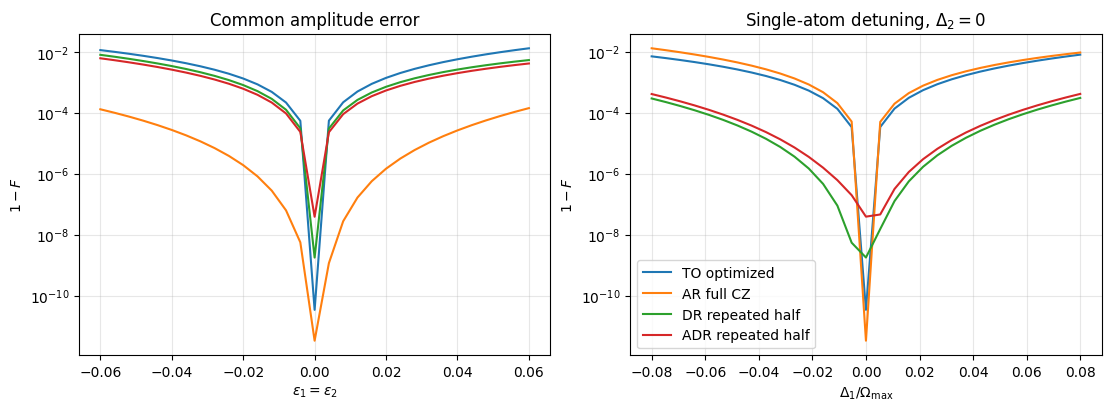

In [18]:
epsilon_grid = np.linspace(-0.06, 0.06, 31)
detuning_grid = np.linspace(-0.08, 0.08, 31)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for label, candidate in candidates.items():
    phases = np.asarray(candidate["phases"], dtype=np.float64)
    total_time = float(candidate["total_time"])
    use_reversal = bool(candidate["use_doppler_reversal"])
    amp_infidelity = [
        evaluate_full_gate(phases, total_time=total_time, amplitude_error=float(value), use_doppler_reversal=use_reversal)["infidelity"]
        for value in epsilon_grid
    ]
    det_infidelity = [
        evaluate_full_gate(phases, total_time=total_time, detuning_1=float(value), use_doppler_reversal=use_reversal)["infidelity"]
        for value in detuning_grid
    ]
    axes[0].semilogy(epsilon_grid, np.maximum(amp_infidelity, 1e-12), label=label)
    axes[1].semilogy(detuning_grid, np.maximum(det_infidelity, 1e-12), label=label)
axes[0].set_title("Common amplitude error")
axes[0].set_xlabel(r"$\epsilon_1=\epsilon_2$")
axes[0].set_ylabel(r"$1-F$")
axes[0].grid(True, which="both", alpha=0.3)
axes[1].set_title(r"Single-atom detuning, $\Delta_2=0$")
axes[1].set_xlabel(r"$\Delta_1/\Omega_{\max}$")
axes[1].set_ylabel(r"$1-F$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(loc="best")
plt.show()


## Phase profiles

The TO and AR pulses are full-CZ phase profiles optimized from zero. The DR and ADR profiles below are selected half-pulse phases from the from-zero duration scan; the full DR/ADR gate repeats the plotted half-pulse exactly once, with the Doppler sign flipped between the two copies by the switch or wait mechanism described above.


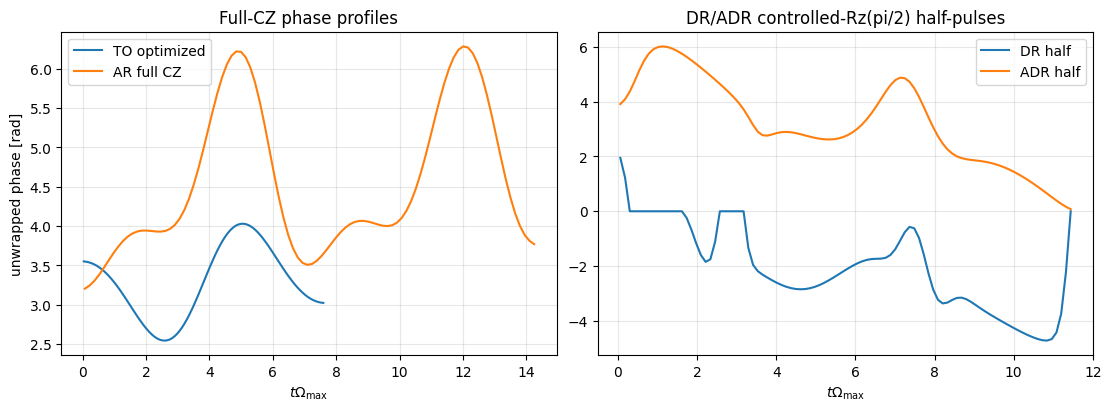

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
if "to_phases" in globals() and "to_time" in globals():
    to_centers = (np.arange(to_phases.size) + 0.5) * to_time / to_phases.size
    axes[0].plot(to_centers, np.unwrap(to_phases), label="TO optimized")
if "ar_phases" in globals() and "full_ar_time" in globals():
    ar_centers = (np.arange(ar_phases.size) + 0.5) * full_ar_time / ar_phases.size
    axes[0].plot(ar_centers, np.unwrap(ar_phases), label="AR full CZ")
axes[0].set_title("Full-CZ phase profiles")
axes[0].set_xlabel(r"$t\Omega_{\max}$")
axes[0].set_ylabel("unwrapped phase [rad]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

has_half_pulses = False
if "dr_half_phases" in globals() and "dr_half_total_time" in globals():
    dr_half_centers = (np.arange(num_half_tslots) + 0.5) * dr_half_total_time / num_half_tslots
    axes[1].plot(dr_half_centers, np.unwrap(dr_half_phases), label="DR half")
    has_half_pulses = True
if "adr_half_phases" in globals() and "adr_half_total_time" in globals():
    adr_half_centers = (np.arange(num_half_tslots) + 0.5) * adr_half_total_time / num_half_tslots
    axes[1].plot(adr_half_centers, np.unwrap(adr_half_phases), label="ADR half")
    has_half_pulses = True
axes[1].set_title("DR/ADR controlled-Rz(pi/2) half-pulses")
axes[1].set_xlabel(r"$t\Omega_{\max}$")
axes[1].grid(True, alpha=0.3)
if has_half_pulses:
    axes[1].legend(loc="best")
else:
    axes[1].text(0.5, 0.5, "DR/ADR stages not run", ha="center", va="center", transform=axes[1].transAxes)
plt.show()


## Interpretation of the production reproduction

This notebook now performs AR/DR/ADR as from-zero robust optimizations: the robust pulses start from deterministic random phase profiles, not from any imported optimized PRX Quantum pulse. TO is also optimized from zero and kept as the sole non-robust comparison row. The pulse construction follows the paper: full-CZ AR, half-pulse DR/ADR, repeated identical halves, and Doppler sign reversal in the second half. The repeated-half construction assumes either the switch method reverses `k`, or the wait method reverses `v` after waiting for a time `pi / omega_trap`; without that sign reversal, repeating the two halves would not implement the paper's DR/ADR cancellation mechanism.

The optimization settings are deliberately production-scale rather than reduced for notebook execution:

- the paper uses GRAPE over piecewise-constant controls with `N >> 1`; this notebook executes `N = 200` phase slots;
- every target uses 32 deterministic random starts per duration and a shared `max_nfev = 10000` for the nominal or robust solve;
- AR, DR, and ADR are optimized from zero with the paper's first-order objectives; TO is optimized from zero and kept as the only non-robust baseline;
- DR and ADR are evaluated only as repeated identical half-pulses with the Doppler sign flipped in the second half.


## Rydberg decay no-jump evaluation

This section does **not** optimize any controls. It loads the current TO/AR/DR/ADR control sequences from `notebooks/artifacts/prxq2023_smooth_4h/` and re-evaluates them with a branch-level non-Hermitian no-jump Rydberg decay term.

The default physical scale follows the current `^{171}Yb` UV notes and calibration helpers: `Omega_max / 2pi = 10 MHz` and Rydberg lifetime `tau_r = 65 us`, giving `gamma/Omega_max = 1 / (Omega_max tau_r)`. In the blockade branches, one-Rydberg states receive the generator contribution `-gamma/2`; the `|00>` branch is unchanged. This is an active-block loss proxy, not a full branching-ratio master equation or erasure-detection model.

The reported `decay_nominal_fidelity` is the no-jump computational-process fidelity after optimizing local `Z` phases, using the diagonal computational Kraus entries. `decay_active_survival` is the average no-jump norm over computational inputs, and `decay_loss_proxy = 1 - decay_active_survival` estimates population lost from the coherent active block through Rydberg decay.


In [ ]:
def branch_decay_diagonals(gamma_over_omega: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    gamma = float(gamma_over_omega)
    return (
        np.diag([0.0, gamma]).astype(np.complex128),
        np.diag([0.0, gamma]).astype(np.complex128),
        np.diag([0.0, gamma, gamma]).astype(np.complex128),
    )


def propagate_blockade_branches_with_decay(
    phases: np.ndarray,
    *,
    total_time: float,
    gamma_over_omega: float,
    amplitude_error: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    use_doppler_reversal: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    phases = normalize_phases(phases)
    signs = np.ones(phases.size, dtype=np.float64)
    if use_doppler_reversal:
        signs[phases.size // 2 :] = -1.0
    decay_diagonals = branch_decay_diagonals(float(gamma_over_omega))
    states = [
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0], dtype=np.complex128),
        np.array([1.0, 0.0, 0.0], dtype=np.complex128),
    ]
    dt = float(total_time) / phases.size
    for index, phase in enumerate(phases):
        hamiltonians = blockade_branch_hamiltonians(
            float(phase),
            amplitude_error=float(amplitude_error),
            detuning_1=float(detuning_1) * float(signs[index]),
            detuning_2=float(detuning_2) * float(signs[index]),
        )
        for branch_index, (hamiltonian, decay_diagonal) in enumerate(zip(hamiltonians, decay_diagonals, strict=True)):
            generator = (-1j * hamiltonian - 0.5 * decay_diagonal) * dt
            states[branch_index] = expm(generator) @ states[branch_index]
    return states[0], states[1], states[2]


def branch_amplitudes_with_decay(
    phases: np.ndarray,
    *,
    total_time: float,
    gamma_over_omega: float,
    amplitude_error: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    use_doppler_reversal: bool = False,
) -> tuple[complex, complex, complex, tuple[np.ndarray, np.ndarray, np.ndarray]]:
    states = propagate_blockade_branches_with_decay(
        phases,
        total_time=total_time,
        gamma_over_omega=gamma_over_omega,
        amplitude_error=amplitude_error,
        detuning_1=detuning_1,
        detuning_2=detuning_2,
        use_doppler_reversal=use_doppler_reversal,
    )
    return complex(states[0][0]), complex(states[1][0]), complex(states[2][0]), states


def evaluate_full_gate_with_decay(
    phases: np.ndarray,
    *,
    total_time: float,
    gamma_over_omega: float,
    amplitude_error: float = 0.0,
    detuning_1: float = 0.0,
    detuning_2: float = 0.0,
    use_doppler_reversal: bool = False,
) -> dict[str, float]:
    alpha10, alpha01, beta11, states = branch_amplitudes_with_decay(
        phases,
        total_time=total_time,
        gamma_over_omega=gamma_over_omega,
        amplitude_error=amplitude_error,
        detuning_1=detuning_1,
        detuning_2=detuning_2,
        use_doppler_reversal=use_doppler_reversal,
    )
    theta10, theta01, process_fidelity = optimize_local_phases(alpha10, alpha01, beta11)
    computational_return_population = (1.0 + abs(alpha10) ** 2 + abs(alpha01) ** 2 + abs(beta11) ** 2) / 4.0
    active_survival = (1.0 + sum(float(np.vdot(state, state).real) for state in states)) / 4.0
    return {
        "process_fidelity": float(process_fidelity),
        "infidelity": float(1.0 - process_fidelity),
        "theta10": float(theta10),
        "theta01": float(theta01),
        "computational_return_population": float(computational_return_population),
        "active_survival": float(active_survival),
        "decay_loss_proxy": float(1.0 - active_survival),
        "coherent_leakage_population": float(max(active_survival - computational_return_population, 0.0)),
    }


def summarize_full_gate_with_decay(
    label: str,
    phases: np.ndarray,
    *,
    total_time: float,
    use_doppler_reversal: bool,
    gamma_over_omega: float,
    closed_nominal_fidelity: float,
) -> dict[str, float | str | bool]:
    nominal = evaluate_full_gate_with_decay(
        phases,
        total_time=total_time,
        gamma_over_omega=gamma_over_omega,
        use_doppler_reversal=use_doppler_reversal,
    )
    amp_min = min(
        evaluate_full_gate_with_decay(
            phases,
            total_time=total_time,
            gamma_over_omega=gamma_over_omega,
            amplitude_error=value,
            use_doppler_reversal=use_doppler_reversal,
        )["process_fidelity"]
        for value in (-0.05, 0.05)
    )
    detuning_minus = evaluate_full_gate_with_decay(
        phases,
        total_time=total_time,
        gamma_over_omega=gamma_over_omega,
        detuning_1=-0.05,
        use_doppler_reversal=use_doppler_reversal,
    )["process_fidelity"]
    detuning_plus = evaluate_full_gate_with_decay(
        phases,
        total_time=total_time,
        gamma_over_omega=gamma_over_omega,
        detuning_1=0.05,
        use_doppler_reversal=use_doppler_reversal,
    )["process_fidelity"]
    return {
        "label": label,
        "total_time_omega": float(total_time),
        "doppler_reversal": bool(use_doppler_reversal),
        "closed_nominal_fidelity": float(closed_nominal_fidelity),
        "decay_nominal_fidelity": float(nominal["process_fidelity"]),
        "nominal_decay_delta": float(nominal["process_fidelity"] - closed_nominal_fidelity),
        "decay_active_survival": float(nominal["active_survival"]),
        "decay_loss_proxy": float(nominal["decay_loss_proxy"]),
        "decay_min_amp_fidelity_pm_0p05": float(amp_min),
        "decay_detuning_fidelity_m0p05": float(detuning_minus),
        "decay_detuning_fidelity_p0p05": float(detuning_plus),
    }


In [ ]:
decay_omega_max_hz = 10.0e6
rydberg_lifetime_s = 65.0e-6
decay_gamma_over_omega = 1.0 / (2.0 * np.pi * decay_omega_max_hz * rydberg_lifetime_s)
closed_summary_by_label = {row["label"]: row for row in summary_rows}

decay_summary_rows = [
    summarize_full_gate_with_decay(
        label,
        np.asarray(candidate["phases"], dtype=np.float64),
        total_time=float(candidate["total_time"]),
        use_doppler_reversal=bool(candidate["use_doppler_reversal"]),
        gamma_over_omega=decay_gamma_over_omega,
        closed_nominal_fidelity=float(closed_summary_by_label[label]["nominal_fidelity"]),
    )
    for label, candidate in candidates.items()
]
for row in decay_summary_rows:
    row["physical_time_us"] = float(row["total_time_omega"] / (2.0 * np.pi * decay_omega_max_hz) * 1e6)

print(f"Rydberg decay no-jump gamma/Omega = {decay_gamma_over_omega:.6e}")
print_summary_table(decay_summary_rows)

save_stage_json(
    stage_artifact_dir / "decay_summary.json",
    {
        "noise_model": "Rydberg decay as branch-level non-Hermitian no-jump term; no pulse reoptimization",
        "omega_max_hz": float(decay_omega_max_hz),
        "rydberg_lifetime_s": float(rydberg_lifetime_s),
        "gamma_over_omega": float(decay_gamma_over_omega),
        "rows": decay_summary_rows,
    },
)


## Decay evaluation result for current pulses

The table below was generated without reoptimization by loading the current TO/AR/DR/ADR phase checkpoints and adding the no-jump Rydberg decay term described above. The physical scale is `Omega_max / 2pi = 10 MHz`, `tau_r = 65 us`, so `gamma/Omega_max = 2.448538e-04`.

| pulse | time (Omega units) | time (us) | closed nominal F | decay nominal F | delta F | decay loss proxy | amp ±5% worst | det -0.05 | det +0.05 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| TO optimized | 7.63407 | 0.1215 | 0.999999999966 | 0.999269721176 | -0.000730279 | 0.000730227 | 0.990136947996 | 0.996420848532 | 0.996169213367 |
| AR full CZ | 14.32 | 0.22791 | 0.999999999997 | 0.998837438139 | -0.00116256 | 0.00116245 | 0.998767978674 | 0.993943630032 | 0.994860997818 |
| DR repeated half | 23 | 0.366056 | 0.999999998219 | 0.998442308684 | -0.00155769 | 0.00155748 | 0.992960542977 | 0.998389258075 | 0.998386624269 |
| ADR repeated half | 23 | 0.366056 | 0.999999960923 | 0.998482953997 | -0.00151701 | 0.00151681 | 0.994298447936 | 0.998406182033 | 0.998406638330 |

Main interpretation: decay penalizes the longer robust pulses even when their coherent control error is small. TO remains best at zero technical noise because it is shortest; AR keeps the best amplitude-noise fidelity; DR and ADR keep the best Doppler/detuning fidelity after decay, but their nominal fidelity is reduced by about `1.5e-3` from Rydberg exposure. DR and ADR have the same total duration in the current checkpoints (`Omega_max*T = 23`), so their decay losses are comparable.


## Final decay fidelity curves

This final panel uses the current optimized control sequences without further optimization. Solid curves include Rydberg no-jump decay with `Omega_max / 2pi = 10 MHz` and `tau_r = 65 us`; dashed curves are the same pulses with `gamma = 0`. The left column scans common amplitude error `epsilon_1 = epsilon_2`; the right column scans `Delta_1 / Omega_max` with `Delta_2 = 0`.

![Decay sensitivity curves](artifacts/prxq2023_smooth_4h/decay_sensitivity_curves.png)
